In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

data = {
    "CustomerID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Gender": ["Male", "Female", "Female", "Male", "Female",
               "Male", "Female", "Male", "Female", "Male"],
    "Age": [19, 21, 20, 23, 31, 22, 35, 40, 30, 25],
    "Annual Income (k$)": [15, 16, 17, 18, 20, 25, 35, 45, 50, 55],
    "Spending Score (1-100)": [39, 81, 6, 77, 40, 76, 6, 40, 60, 70]
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv("Mall_Customers.csv", index=False)

print("Dataset created successfully!")
print(df)


Dataset created successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  16                      81
2           3  Female   20                  17                       6
3           4    Male   23                  18                      77
4           5  Female   31                  20                      40
5           6    Male   22                  25                      76
6           7  Female   35                  35                       6
7           8    Male   40                  45                      40
8           9  Female   30                  50                      60
9          10    Male   25                  55                      70


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Dataset information
print("Dataset Information:")
df.info()

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Data types of all columns
print("\nData Types:")
print(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              10 non-null     int64 
 1   Gender                  10 non-null     object
 2   Age                     10 non-null     int64 
 3   Annual Income (k$)      10 non-null     int64 
 4   Spending Score (1-100)  10 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 532.0+ bytes

Summary Statistics:
       CustomerID       Age  Annual Income (k$)  Spending Score (1-100)
count    10.00000  10.00000           10.000000               10.000000
mean      5.50000  26.60000           29.600000               49.500000
std       3.02765   7.07421           15.392639               28.000992
min       1.00000  19.00000           15.000000                6.000000
25%       3.25000  21.25000           17.250000               39.250000
50%   

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select relevant numerical features
features = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print("Selected Numerical Features:")
print(features.head())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("\nStandardized Data:")
print(X_scaled[:5])


Selected Numerical Features:
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  16                      81
2   20                  17                       6
3   23                  18                      77
4   31                  20                      40

Standardized Data:
[[-1.13243791 -0.9998124  -0.3952707 ]
 [-0.83442794 -0.9313321   1.18581211]
 [-0.98343293 -0.8628518  -1.63755006]
 [-0.53641796 -0.7943715   1.03523279]
 [ 0.65562195 -0.65741089 -0.35762587]]


Dataset with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  
5        0  
6        1  
7        1  
8        1  
9        1  


C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


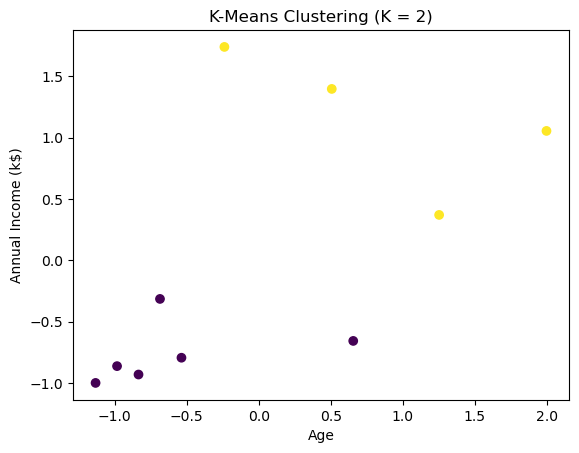

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select relevant numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with K = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Generate cluster labels
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df["Cluster"] = labels

# Display first 10 records
print("Dataset with Cluster Labels:")
print(df.head(10))

# Visualize the clusters
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("K-Means Clustering (K = 2)")
plt.show()

C:\Users\Palak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Dataset with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Cluster  
0        0  
1        0  
2        1  
3        0  
4        1  
5        0  
6        1  
7        2  
8        2  
9        2  


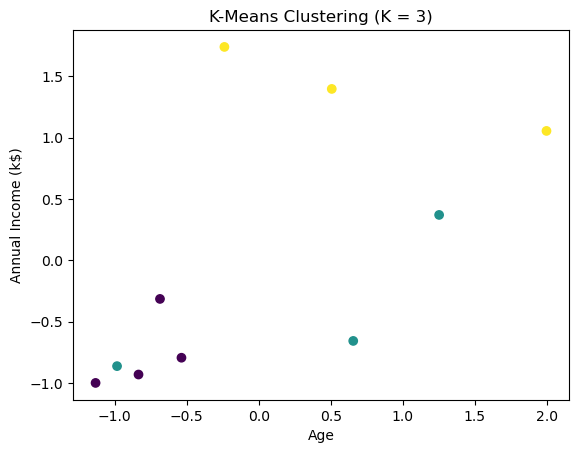

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select relevant numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with K = 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Generate cluster labels
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df["Cluster"] = labels

# Display first 10 records
print("Dataset with Cluster Labels:")
print(df.head(10))

# Visualize the clusters
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("K-Means Clustering (K = 3)")
plt.show()

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Create cluster labels
labels = kmeans.fit_predict(X_scaled)

# Add labels to original dataset
df["Cluster"] = labels

# Display dataset
print("Dataset with Cluster Labels:")
print(df.head(10))

Dataset with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Cluster  
0        0  
1        0  
2        1  
3        0  
4        1  
5        0  
6        1  
7        2  
8        2  
9        2  


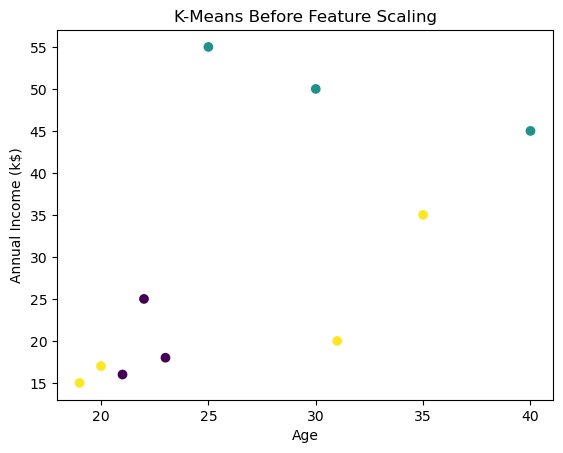

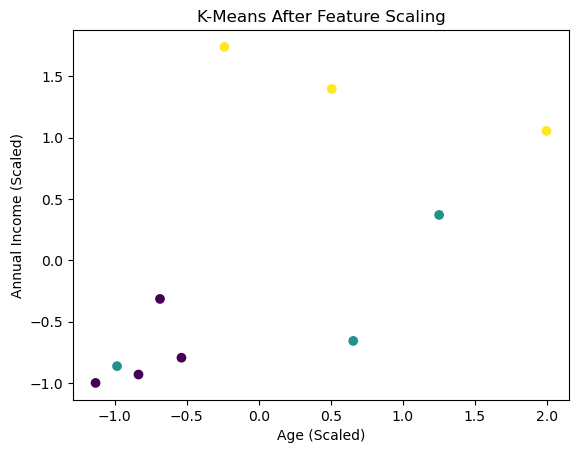

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# K-Means BEFORE scaling
kmeans_before = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_before = kmeans_before.fit_predict(X)

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means AFTER scaling
kmeans_after = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_after = kmeans_after.fit_predict(X_scaled)

# Before scaling
plt.scatter(
    X["Age"],
    X["Annual Income (k$)"],
    c=labels_before
)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("K-Means Before Feature Scaling")
plt.show()

# After scaling
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_after
)

plt.xlabel("Age (Scaled)")
plt.ylabel("Annual Income (Scaled)")
plt.title("K-Means After Feature Scaling")
plt.show()

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)

# Add cluster labels
df["Cluster"] = labels

print("Hierarchical Clustering Results:")
print(df.head(10))

Hierarchical Clustering Results:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        1  
5        0  
6        1  
7        1  
8        2  
9        2  


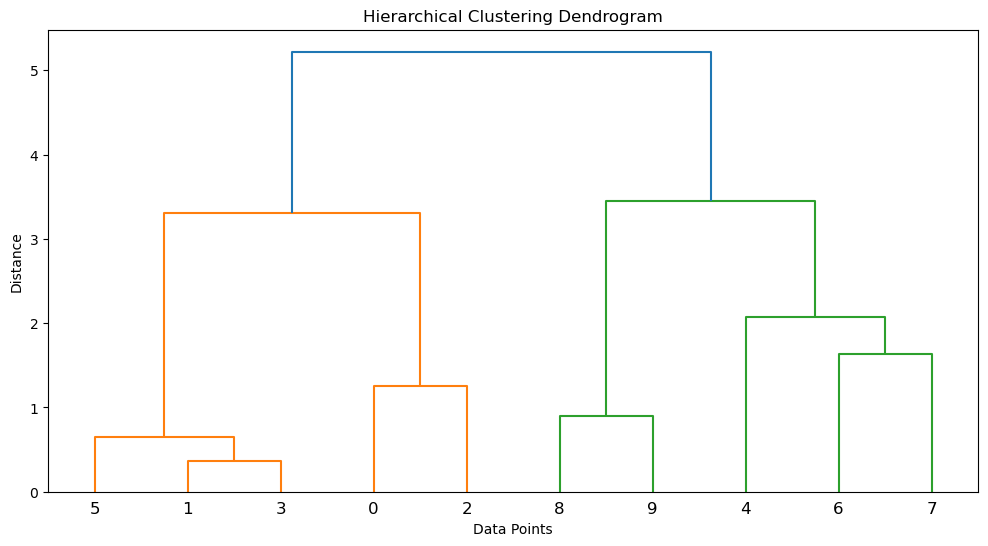

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select numerical features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Generate linkage matrix
linked = linkage(
    X_scaled,
    method="ward"
)

# Generate dendrogram
plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ward linkage
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)

# Add labels
df["Ward_Cluster"] = labels

print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Ward_Cluster  
0             0  
1             0  
2             0  
3             0  
4             1  
5             0  
6             1  
7             1  
8             2  
9    

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Complete linkage
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete"
)

labels = model.fit_predict(X_scaled)

# Add labels
df["Complete_Cluster"] = labels

print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  18                      77   
4           5  Female   31                  20                      40   
5           6    Male   22                  25                      76   
6           7  Female   35                  35                       6   
7           8    Male   40                  45                      40   
8           9  Female   30                  50                      60   
9          10    Male   25                  55                      70   

   Complete_Cluster  
0                 2  
1                 0  
2                 2  
3                 0  
4                 2  
5                 0  
6                 1  
7        

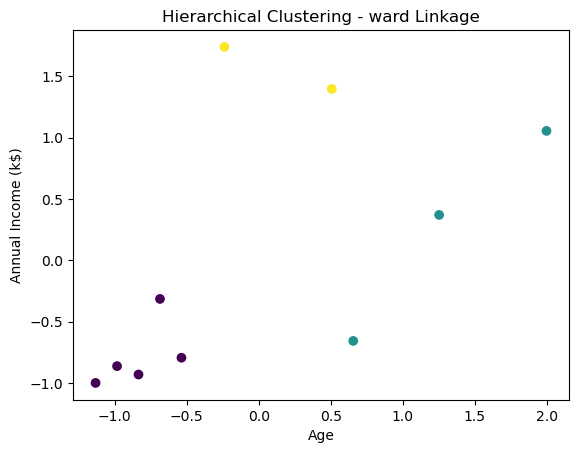

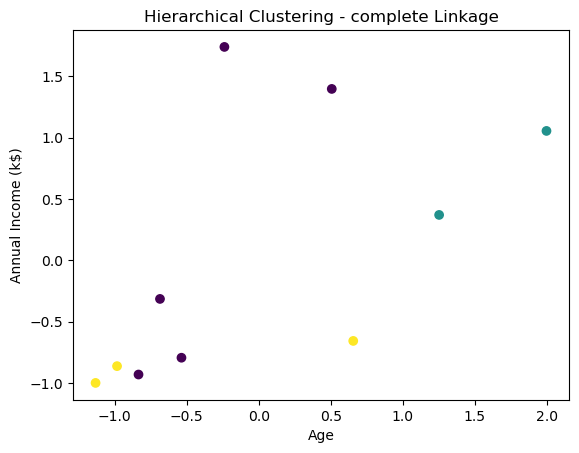

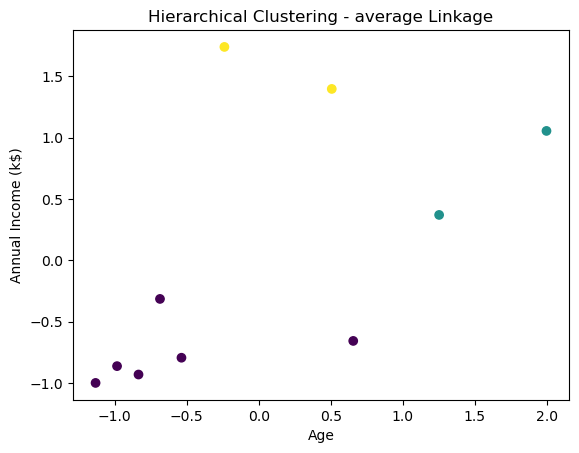

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linkage methods
methods = ["ward", "complete", "average"]

for method in methods:

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = model.fit_predict(X_scaled)

    plt.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels
    )

    plt.xlabel("Age")
    plt.ylabel("Annual Income (k$)")
    plt.title(f"Hierarchical Clustering - {method} Linkage")

    plt.show()

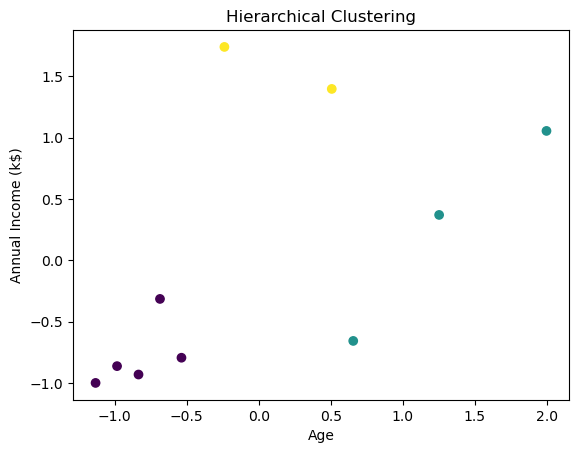

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hierarchical Clustering
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)

# Visualization
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Hierarchical Clustering")

plt.show()

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Transformed Data:")
print(X_pca[:10])

PCA Transformed Data:
[[-1.3333708  -0.7502322 ]
 [-1.52949452  0.65645748]
 [-0.78266737 -1.78875877]
 [-1.18495331  0.57038993]
 [ 0.1614177  -0.66317258]
 [-0.97955247  0.771467  ]
 [ 1.60638684 -1.34317544]
 [ 2.20762464  0.06123313]
 [ 1.13221552  0.97437618]
 [ 0.70239378  1.51141527]]


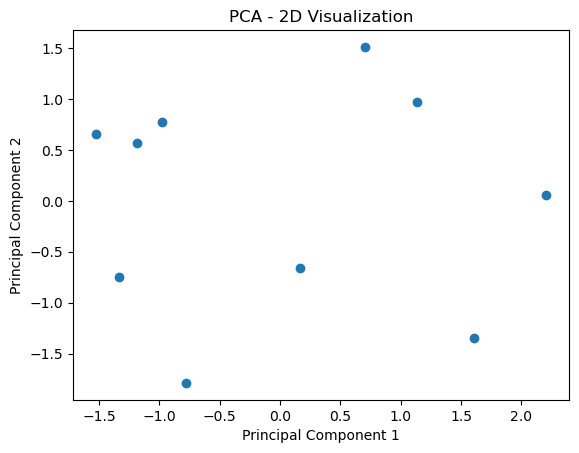

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Visualization
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")

plt.show()

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

pca.fit(X_scaled)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.54496156 0.35318005]


In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with all components
pca = PCA()

pca.fit(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_

# Cumulative variance
cumulative_variance = explained_variance.cumsum()

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

Explained Variance Ratio:
[0.54496156 0.35318005 0.1018584 ]

Cumulative Explained Variance:
[0.54496156 0.8981416  1.        ]


In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print("Original Dataset Shape:")
print(X.shape)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nDataset Shape After PCA:")
print(X_pca.shape)

Original Dataset Shape:
(10, 3)

Dataset Shape After PCA:
(10, 2)


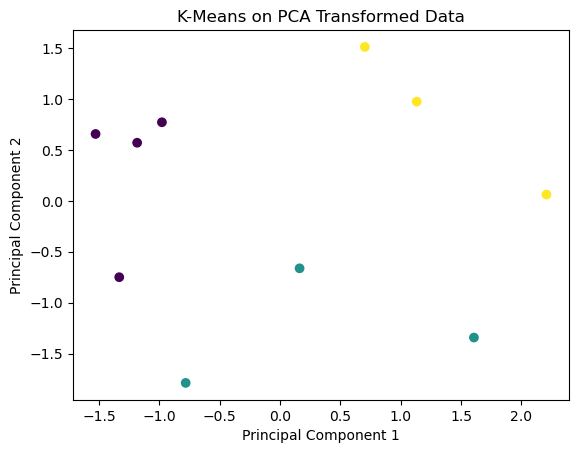

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

# Visualization
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means on PCA Transformed Data")

plt.show()

In [15]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

# Silhouette Score
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.336664981076698


In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different K values
for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.3656
K = 3, Silhouette Score = 0.3367
K = 4, Silhouette Score = 0.4759
K = 5, Silhouette Score = 0.4340
K = 6, Silhouette Score = 0.3944
K = 7, Silhouette Score = 0.3153


In [17]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster characteristics
print("Cluster Characteristics:")
print(
    df.groupby("Cluster")[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ].mean()
)

Cluster Characteristics:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        21.250000                18.5               68.250000
1        28.666667                24.0               17.333333
2        31.666667                50.0               56.666667


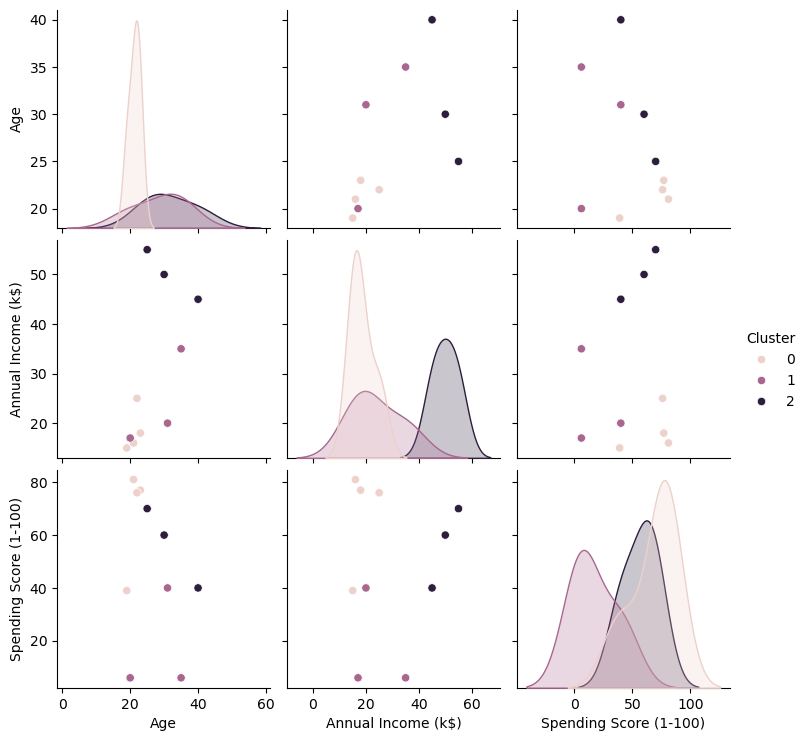

In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Pair plot
sns.pairplot(
    df,
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    hue="Cluster"
)

plt.show()

In [19]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Save dataset
df.to_csv(
    "clustered_mall_customers.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


In [20]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- K-MEANS ----------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

# -------- HIERARCHICAL CLUSTERING --------

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

# Display results
print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 4))

# Compare
if kmeans_score > hierarchical_score:
    print("\nK-Means performs better.")
elif hierarchical_score > kmeans_score:
    print("\nHierarchical Clustering performs better.")
else:
    print("\nBoth methods have equal performance.")

K-Means Silhouette Score: 0.3367
Hierarchical Silhouette Score: 0.3749

Hierarchical Clustering performs better.


In [21]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- K-MEANS ----------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

# -------- HIERARCHICAL CLUSTERING --------

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

# Display results
print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 4))

# Compare
if kmeans_score > hierarchical_score:
    print("\nK-Means performs better.")
elif hierarchical_score > kmeans_score:
    print("\nHierarchical Clustering performs better.")
else:
    print("\nBoth methods have equal performance.")

K-Means Silhouette Score: 0.3367
Hierarchical Silhouette Score: 0.3749

Hierarchical Clustering performs better.


In [22]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3367


In [23]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.3656
K = 3, Silhouette Score = 0.3367
K = 4, Silhouette Score = 0.4759
K = 5, Silhouette Score = 0.4340
K = 6, Silhouette Score = 0.3944
K = 7, Silhouette Score = 0.3153


In [24]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        21.250000                18.5               68.250000
1        28.666667                24.0               17.333333
2        31.666667                50.0               56.666667


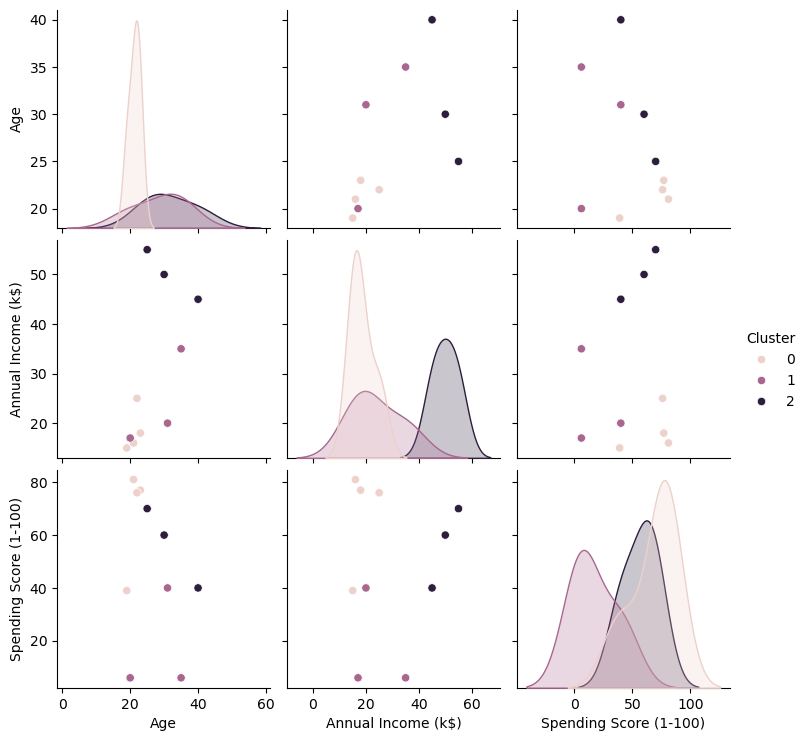

In [25]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

sns.pairplot(
    df,
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    hue="Cluster"
)

plt.show()

In [26]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.to_csv(
    "clustered_mall_customers.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


In [27]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 4))

if kmeans_score > hierarchical_score:
    print("\nK-Means performs better.")
elif hierarchical_score > kmeans_score:
    print("\nHierarchical Clustering performs better.")
else:
    print("\nBoth methods perform equally.")

K-Means Silhouette Score: 0.3367
Hierarchical Silhouette Score: 0.3749

Hierarchical Clustering performs better.
